<a href="https://colab.research.google.com/github/guadalupesbel-commits/EstadisticaVerano2026/blob/main/Problema02_u4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2. **Comparación de cuatro tipos de cuero:** Un fabricante de calzado desea mejorar la calidad de las suelas, las cuales se pueden hacer con uno de los cuatro tipos de cuero A, B, C y D disponibles en el mercado. Para ello, prueba los cueros con una máquina que hace pasar los zapatos por una superficie abrasiva; la suela de éstos se desgasta al pasarla por dicha superficie. Como criterio de desgaste se usa la pérdida de peso después de un número fijo de ciclos. Se prueban en orden aleatorio 24 zapatos, seis de cada tipo de cuero. Al hacer las pruebas en orden completamente al azar se evitan sesgos y las mediciones en un tipo de cuero resultan independientes de las demás. Los datos (en miligramos) sobre el desgaste de cada tipo de cuero se muestran en la tabla.

| Tipo de cuero | Observaciones                  | Promedio |
|---------------|--------------------------------|----------|
| A             | 264, 260, 258, 241, 262, 255 | 256.7    |
| B             | 208, 220, 216, 200, 213, 206 | 209.8    |
| C             | 220, 263, 219, 225, 230, 228 | 230.8    |
| D             | 217, 226, 215, 227, 220, 222 | 220.7    |


In [ ]:
import pandas as pd
from io import StringIO

datos = """
cuero,observaciones
A,264
B,208
C,220
D,217
A,260
B,220
C,263
D,226
A,258
B,216
C,219
D,215
A,241
B,200
C,225
D,227
A,262
B,213
C,230
D,220
A,255
B,206
C,228
D,222
"""

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,cuero,observaciones
0,A,264
1,B,208
2,C,220
3,D,217
4,A,260
5,B,220
6,C,263
7,D,226
8,A,258
9,B,216


In [ ]:
df.columns

Index(['cuero', 'observaciones'], dtype='object')

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('observaciones ~ C(cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales

,sum_sq,df,F,PR(>F)
C(cuero),7019.4583,3.0,22.7554,0.0
Residual,2056.5000,20.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.009670145138301391


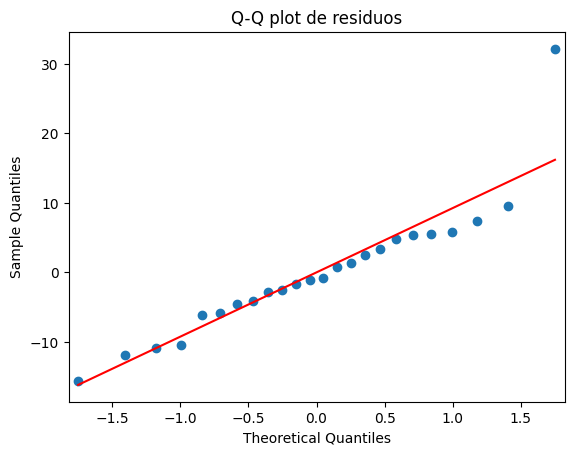

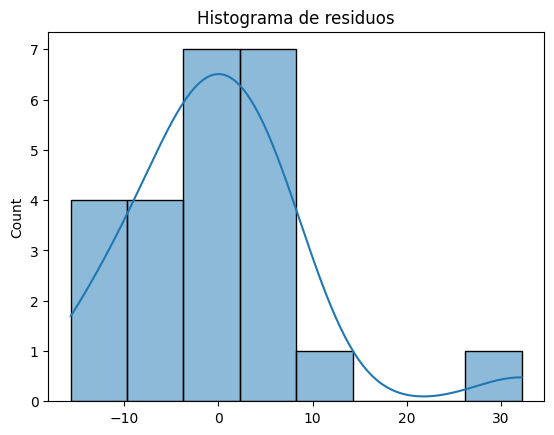

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['cuero'] == 'A']['observaciones']
grupo_B = df[df['cuero'] == 'B']['observaciones']
grupo_C = df[df['cuero'] == 'C']['observaciones']
grupo_D = df[df['cuero'] == 'D']['observaciones']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.5797
p-valor: 0.6351


Lambda óptimo: -3.707788382033557


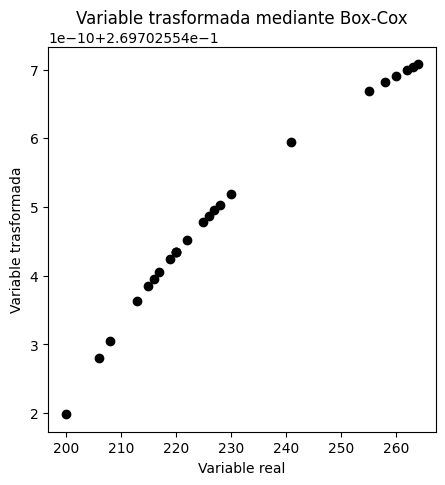

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["observaciones_boxcox"], lambda_opt = boxcox(df["observaciones"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["observaciones"], df["observaciones_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('observaciones_boxcox ~ C(cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales

,sum_sq,df,F,PR(>F)
C(cuero),0.0,3.0,23.3682,0.0
Residual,0.0,20.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.4576969192784245


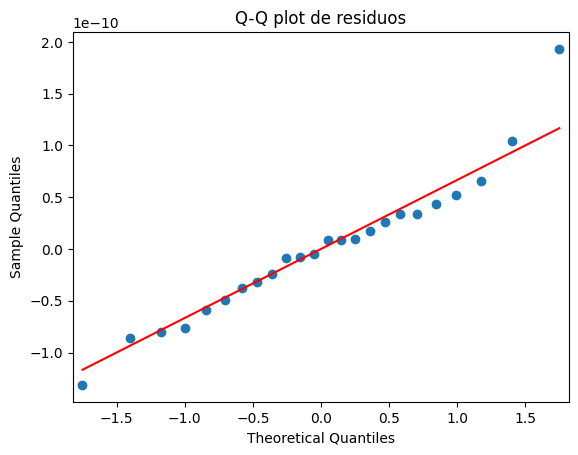

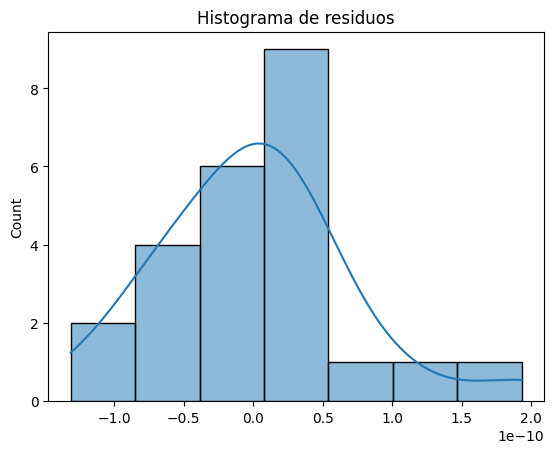

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['cuero'] == 'A']['observaciones_boxcox']
grupo_B = df[df['cuero'] == 'B']['observaciones_boxcox']
grupo_C = df[df['cuero'] == 'C']['observaciones_boxcox']
grupo_D = df[df['cuero'] == 'D']['observaciones_boxcox']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 1.1788
p-valor: 0.3428


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower upper reject
------------------------------------------------
     A      B     -0.0    0.0  -0.0  -0.0   True
     A      C     -0.0 0.0048  -0.0  -0.0   True
     A      D     -0.0 0.0001  -0.0  -0.0   True
     B      C      0.0 0.0018   0.0   0.0   True
     B      D      0.0 0.0613  -0.0   0.0  False
     C      D     -0.0  0.401  -0.0   0.0  False
------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

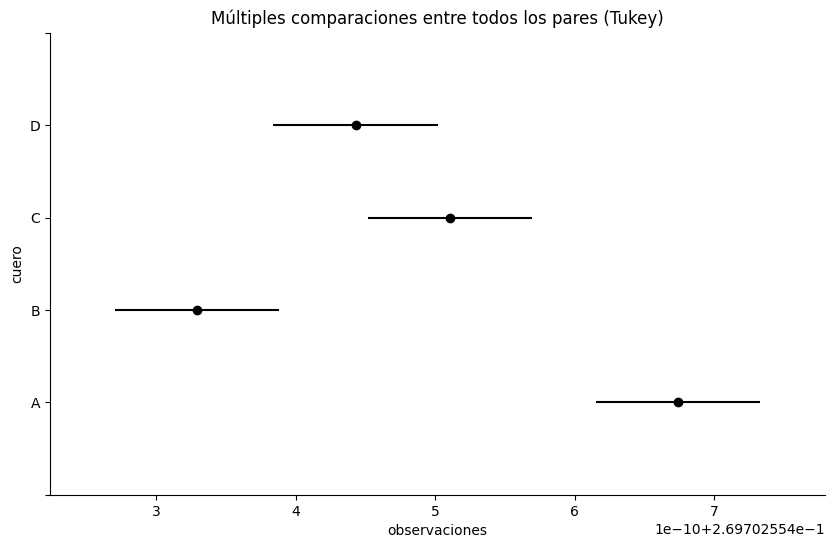

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['observaciones_boxcox'], # Variable de respuesta
    groups=df['cuero'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="cuero", xlabel="observaciones")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["cuero"]).mean()["observaciones"]

,observaciones
cuero,
A,256.666667
B,210.500000
C,230.833333
D,221.166667


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(cuero)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.773


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["cuero"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.7734
f de Cohen = 1.8475
Potencia de la prueba = 1.0000


In [ ]:
n_necesario = analisis_potencia.solve_power(
    effect_size=f_cohen,
    alpha=0.05,
    power=0.80,   # Potencia de la prueba
    k_groups=k_grupos
)

print(f"Observaciones totales necesarias: {n_necesario:.2f}")
print(f"Observaciones por grupo: {np.ceil(n_necesario / k_grupos):.0f}")

Observaciones totales necesarias: 8.28
Observaciones por grupo: 3


Conclusión:

Los tipos de cuero probados dieron como resultado que los mejores o más duraderos según el diseño experimental DCA que los cueros tipo B y D cumplen con los supuestos de normalidad y homoscedasticidad y no hay diferencia significativa entre ellos.
El cuero tipo C muestra una pequeña diferencia que pordría conciderarse nuestro plan B en caso de algún imprevisto con los cueros que tienen mayoe calidad.
A comparación del cuero tipo A si muestra niveles más bajos de calidad por lo que si recomendamos evitarlo.

El tamaño del efecto es de 0.7734, lo que indica que el cambio en los métodos de ensamble justifica en un 77.34% los cambios observados en los tiempos de ensamble. La potencia de la prueba de 1.00 indica que tenemos un 100% de probabilidad de rechazar la hipótesis nula dado que es falsa. Esto le da mucho sustento a los resultados observados.

Si quisieramos trabajar con una potencia de la prueba del 80%, sólo hacían falta 3 observaciones por grupo. Al tener 4, reforzamos las conclusiones del estudio.